<a href="https://colab.research.google.com/github/ShamimtheAnalyst/Crash-Course/blob/main/Mastering_Boxplots_in_ggplot2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Mastering Boxplots: Visualizing Data Distribution and Outliers**

### নোটবুক পরিচিতি (Metadata)
- Aim: আর (R) এবং ggplot2 ব্যবহার করে বিভিন্ন ক্যাটাগরির ডেটার ডিস্ট্রিবিউশন বা বিস্তৃতি দেখা এবং ৫-নম্বর সামারি (Min, Q1, Median, Q3, Max) ও আউটলায়ার চিহ্নিত করা।
- Dataset: msleep (স্তন্যপায়ী প্রাণীদের ঘুমের তথ্য)।
- Key Learnings: বক্সপ্লট অ্যানাটমি, ডেটা ক্লিনিং (drop_na), ফিল বনাম কালার, এবং কোঅর্ডিনেট ফ্লিপিং।

### কেন বক্সপ্লট ব্যবহার করবেন?
- ১. ডেটার গড় (Median) এবং ভ্যারিয়েশন (Range) সহজে দেখতে।
- ২. ডেটাসেটে কোনো ভুল বা অস্বাভাবিক মান (Outliers) আছে কি না তা বুঝতে।
- ৩. একাধিক গ্রুপের মধ্যে তুলনামূলক বিশ্লেষণ করতে।

![](https://www.simplypsychology.org/wp-content/uploads/box-plot.png)

### ১. এনভায়রনমেন্ট সেটআপ (Setup)
শুরুতেই প্রয়োজনীয় লাইব্রেরি লোড করে নিই।

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
# msleep ডাটাসেট দেখা
head(msleep, 8)

name,genus,vore,order,conservation,sleep_total,sleep_rem,sleep_cycle,awake,brainwt,bodywt
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Cheetah,Acinonyx,carni,Carnivora,lc,12.1,NA,NA,11.9,NA,50.000
Owl monkey,Aotus,omni,Primates,NA,17.0,1.8,NA,7.0,0.01550,0.480
Mountain beaver,Aplodontia,herbi,Rodentia,nt,14.4,2.4,NA,9.6,NA,1.350
Greater short-tailed shrew,Blarina,omni,Soricomorpha,lc,14.9,2.3,0.1333333,9.1,0.00029,0.019
Cow,Bos,herbi,Artiodactyla,domesticated,4.0,0.7,0.6666667,20.0,0.42300,600.000
Three-toed sloth,Bradypus,herbi,Pilosa,NA,14.4,2.2,0.7666667,9.6,NA,3.850
Northern fur seal,Callorhinus,carni,Carnivora,vu,8.7,1.4,0.3833333,15.3,NA,20.490
Vesper mouse,Calomys,NA,Rodentia,NA,7.0,NA,NA,17.0,NA,0.045


In [3]:
names(msleep)

[1] "name"         "genus"        "vore"         "order"        "conservation"
 [6] "sleep_total"  "sleep_rem"    "sleep_cycle"  "awake"        "brainwt"     
[11] "bodywt"

### ২. বেসিক বক্সপ্লট (The Foundation)
আমরা দেখব প্রাণীদের খাদ্যাভ্যাস (vore) অনুযায়ী তাদের ঘুমের পরিমাণের (sleep_total) মধ্যে কী পার্থক্য আছে।

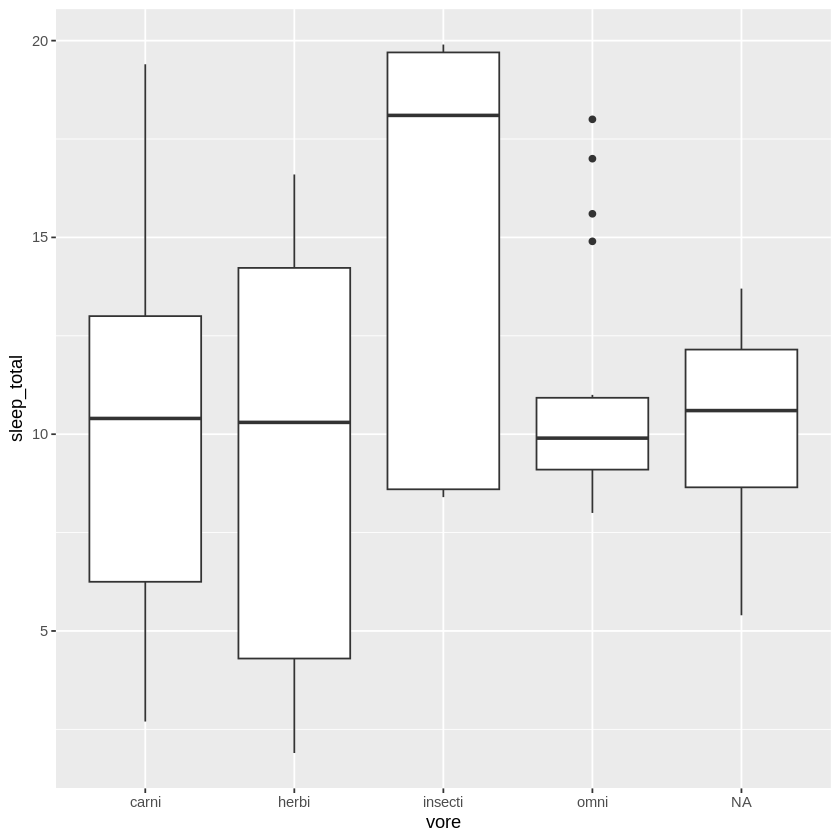

In [4]:
# ধাপ ১: সাধারণ বক্সপ্লট
msleep %>%
  ggplot(aes(vore, sleep_total)) +
  geom_boxplot()

**ব্যাখ্যা:** ডিফল্ট গ্রাফে আমরা দেখতে পাচ্ছি একটি 'NA' ক্যাটাগরি আছে এবং গ্রাফটি দেখতে কিছুটা সাদামাটা।

### ৩. ডেটা ক্লিনিং: drop_na() এর কৌশল
মিসিং ভ্যালু থাকলে গ্রাফে ভুল বার্তা যেতে পারে। এখানে দুটি পদ্ধতি আছে:

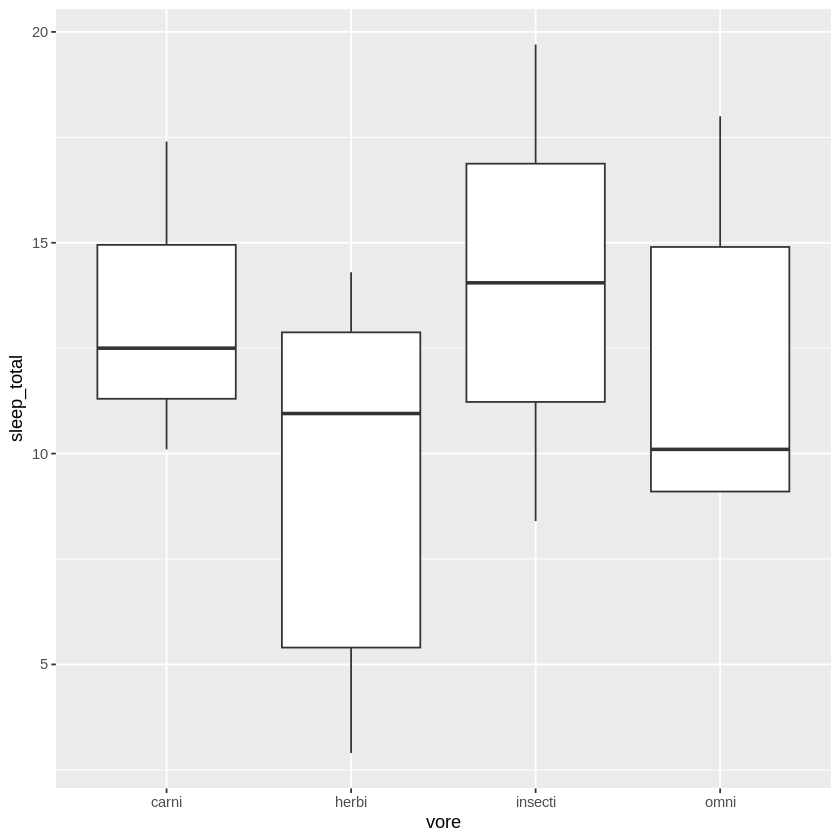

In [5]:
# ধাপ ২: NA হ্যান্ডলিং
# পদ্ধতি ক: drop_na() -> পুরো রো-তে কোথাও NA থাকলে সেটি বাদ দিবে।

msleep %>%
  drop_na() %>%
  ggplot(aes(vore, sleep_total)) +
  geom_boxplot()

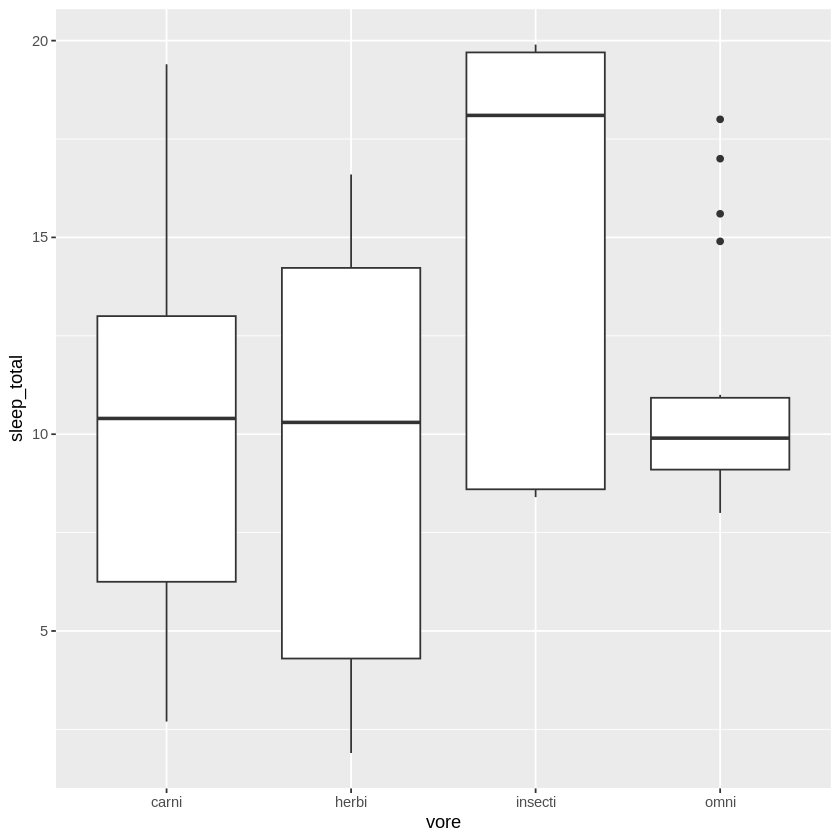

In [6]:
# পদ্ধতি খ: drop_na(vore) -> শুধু vore কলামে NA থাকলে সেটি বাদ দিবে।
msleep %>%
  drop_na(vore) %>%
  ggplot(aes(vore, sleep_total)) +
  geom_boxplot()

**টিপস:** সাধারণত drop_na(column_name) ব্যবহার করা নিরাপদ, কারণ এতে অন্য দরকারি ডেটাগুলো হারিয়ে যাওয়ার ভয় থাকে না।

### ৪. কালার এবং ফিল কাস্টমাইজেশন (Styling Aesthetics)
বক্সপ্লটের সৌন্দর্য বাড়াতে আমরা color এবং fill ব্যবহার করি।

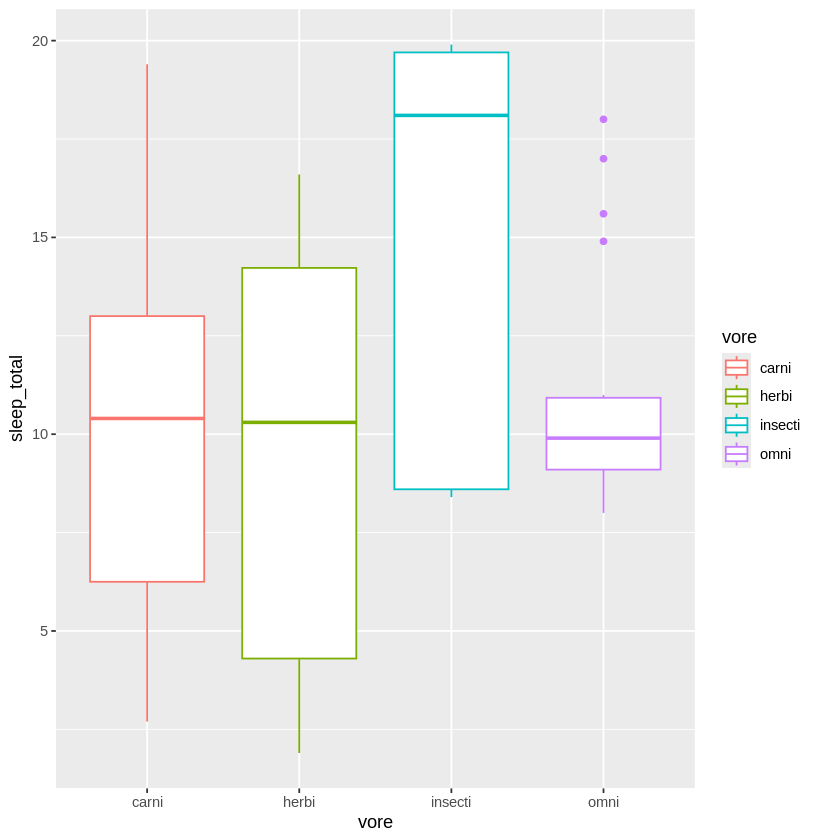

In [7]:
# ধাপ ৩ ও ৪: লাইন কালার বনাম বডি কালার
# কালার দিলে শুধু বর্ডার এবং আউটলায়ার রঙিন হবে
msleep %>%
  drop_na(vore) %>%
  ggplot(aes(vore, sleep_total, color = vore)) +
  geom_boxplot()

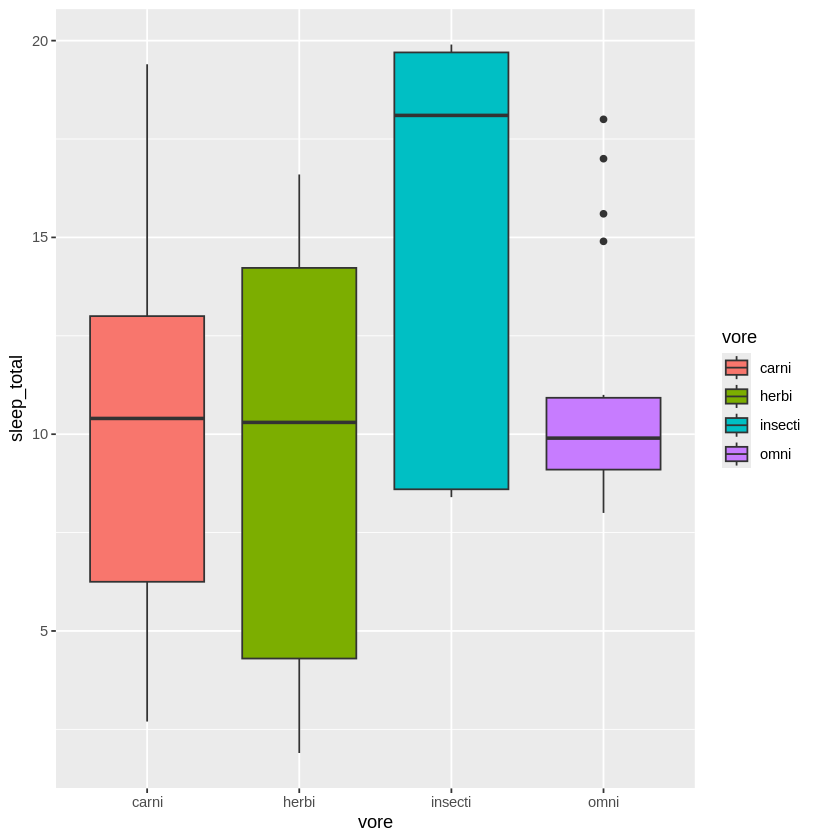

In [8]:
# ফিল দিলে পুরো বক্সটি রঙিন হবে

msleep %>%
  drop_na(vore) %>%
  ggplot(aes(vore, sleep_total, fill = vore)) +
  geom_boxplot()

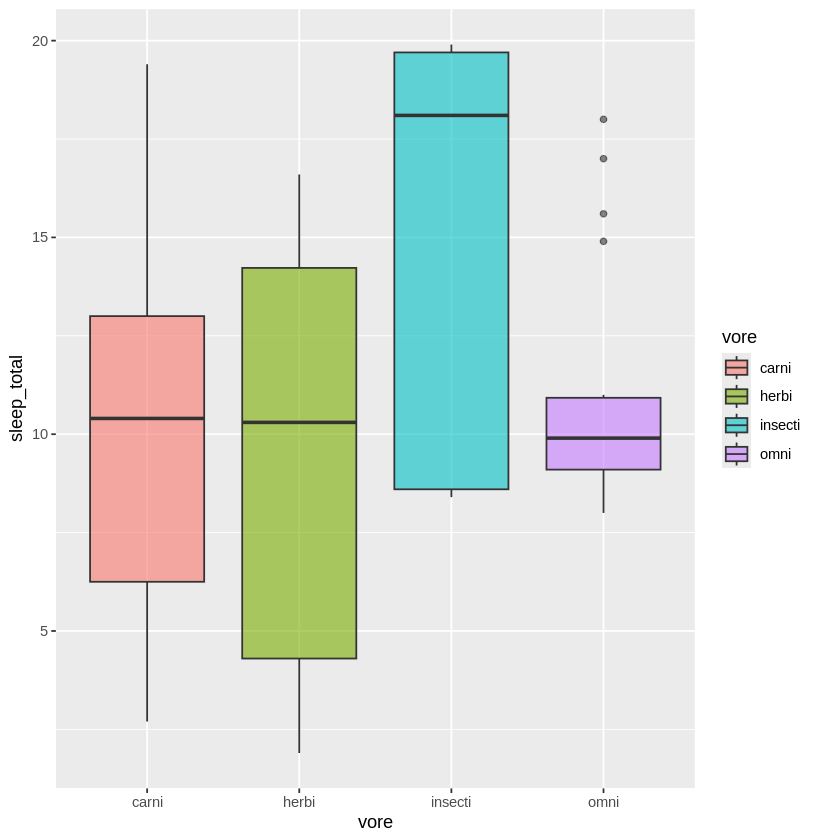

In [9]:
# ফিল দিলে পুরো বক্সটি রঙিন হবে এবং স্বচ্ছতা যোগ করা হয়েছে

msleep %>%
  drop_na(vore) %>%
  ggplot(aes(vore, sleep_total, fill = vore)) +
  geom_boxplot(alpha = 0.6) # স্বচ্ছতা যোগ করা হয়েছে

**ব্যাখ্যা:** fill পুরো বক্সটিকে ভরাট করে ফেলে, আর alpha ব্যবহার করলে রঙটি চোখের জন্য আরামদায়ক হয়।

### ৫. থিম এবং লেবেলিং (Professional Finish)
একটি প্রফেশনাল রিপোর্টের জন্য সঠিক শিরোনাম এবং পরিষ্কার ব্যাকগ্রাউন্ড থাকা জরুরি।

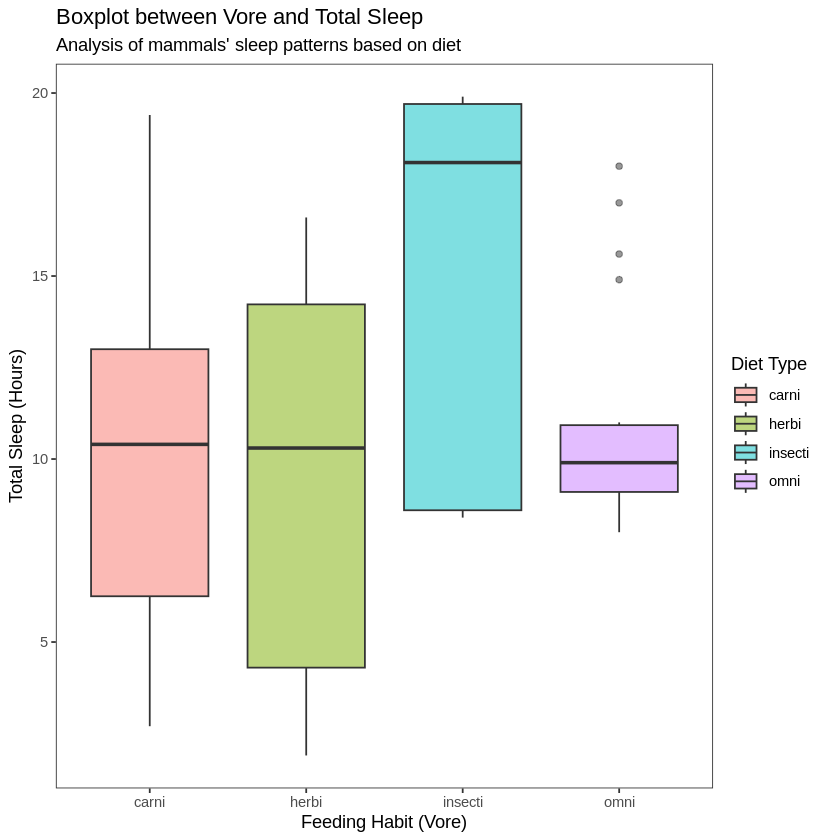

In [10]:
# ধাপ ৫ ও ৬: থিম এবং লেবেল যোগ করা
msleep %>%
  drop_na(vore) %>%
  ggplot(aes(vore, sleep_total, fill = vore)) +
  geom_boxplot(alpha = 0.5) +
  theme_test() + # ক্লিন ব্যাকগ্রাউন্ড
  labs(title = "Boxplot between Vore and Total Sleep",
       subtitle = "Analysis of mammals' sleep patterns based on diet",
       x = "Feeding Habit (Vore)",
       y = "Total Sleep (Hours)",
       fill = "Diet Type")

### ৬. চার্ট ফ্লিপিং (Horizontal Boxplot)
কখনও কখনও ক্যাটাগরির নামগুলো বড় হলে চার্টটি ঘুরিয়ে দেওয়া বেশি অর্থবহ হয়।

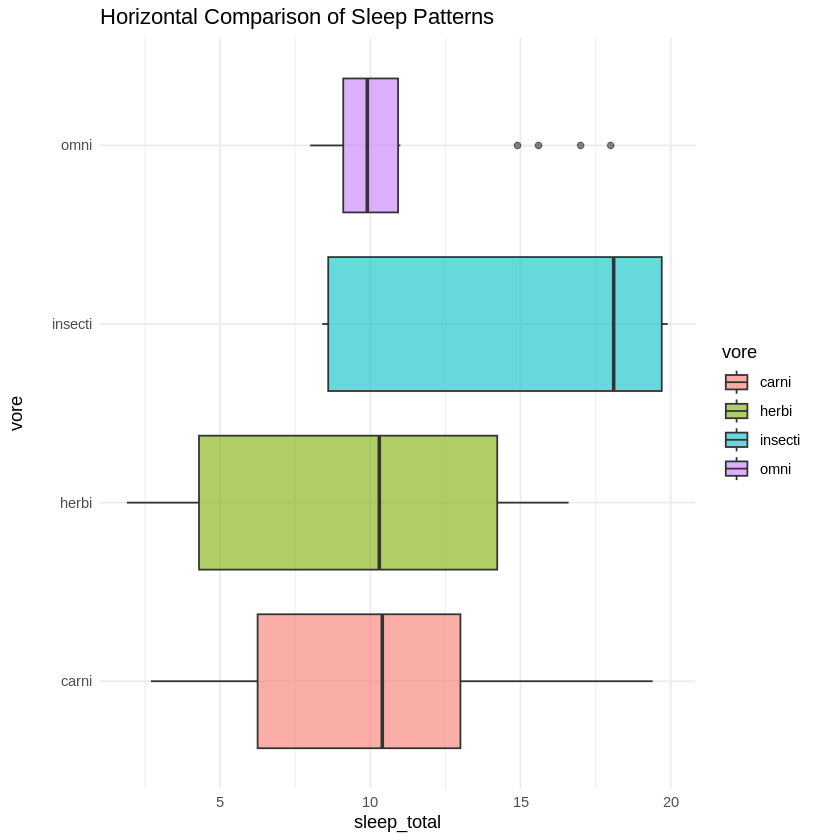

In [11]:
# ধাপ ৭: কোঅর্ডিনেট ফ্লিপ করা
msleep %>%
  drop_na(vore) %>%
  ggplot(aes(vore, sleep_total, fill = vore)) +
  geom_boxplot(alpha = 0.6) +
  coord_flip() + # ভার্টিক্যাল থেকে হরিজন্টাল করা
  theme_minimal() +
  labs(title = "Horizontal Comparison of Sleep Patterns")

### এক নজরে আপনার শেখা টুলকিট (Cheat Sheet):
- geom_boxplot(): বক্সপ্লট তৈরির মেইন ফাংশন।
- drop_na(column): গ্রাফ থেকে অদরকারি NA ভ্যালু সরাতে।
- fill = group: গ্রুপ অনুযায়ী বক্সে রঙ দিতে।
- alpha: রঙের ঘনত্ব কমাতে বা স্বচ্ছতা বাড়াতে।
- coord_flip(): বক্সগুলোকে পাশাপাশি না রেখে ওপর-নিচ (Horizontal) করতে।

**অভিনন্দন!** আপনি বক্সপ্লটের মাধ্যমে ডেটার ডিস্ট্রিবিউশন বিশ্লেষণ করার সবকটি ধাপ শিখে ফেলেছেন।